In [1]:
from pathlib import Path
import pickle

import numpy as np
from scipy import constants as cst

import matplotlib.pyplot as plt
import tqdm

from centrex_tlf import states, hamiltonian, transitions, couplings, lindblad, utils
from centrex_tlf_julia_extension import lindblad_julia
# import cv2
import numpy as np
from scipy.optimize import curve_fit
import scipy.ndimage as ndimage

from PIL import Image

In [2]:
plt.rcParams.update({"font.size": 14})

In [3]:
cwd = Path().cwd()

# Setting up the system

In [4]:
trans = [
    transitions.OpticalTransition(
        transitions.OpticalTransitionType.R, J_ground=2, F1=7 / 2, F=4
    )
]

polarizations = [[couplings.polarization_Z]]

transition_selectors = couplings.generate_transition_selectors(
    trans,
    polarizations,
    ground_mains=[
        1
        * states.CoupledBasisState(
            J=2,
            F=3,
            F1=5 / 2,
            mF=-1,
            I1=1 / 2,
            I2=1 / 2,
            Ω=0,
            P=+1,
            electronic_state=states.ElectronicState.X,
        )
    ],
    excited_mains=[
        1
        * states.CoupledBasisState(
            J=3,
            F=4,
            F1=7 / 2,
            mF=-1,
            I1=1 / 2,
            I2=1 / 2,
            Ω=1,
            P=-1,
            electronic_state=states.ElectronicState.B,
        )
    ],
)

In [5]:
v_to_Γ = utils.detuning.velocity_to_detuning(1)

odepars = lindblad_julia.odeParameters(
    Ω0="rabi_from_intensity(gaussian_2d_rotated(vz*t, y0+vy*t, peak_intensity, laser_center_z, laser_center_y, σz, σy, θ), main_coupling)",
    peak_intensity=1000.0,
    δ0=f"laser_detuning+vx*{v_to_Γ}",  # detuning of the laser [rad/s]
    # laser phase modulation
    ωphase=hamiltonian.Γ,  # laser phase modulation frequency [rad/s]
    β=0,  # laser phase modulation depth [rad]
    PZ0=1,
    # molecules
    z0=-0.03,  # molecule start z position [m]
    vz=184,  # longitudinal molecular velocity [m/s]
    vx=0,
    y0=0.0,
    vy=0.0,
    σz=4.53e-4,
    σy=1.04e-3,
    θ=0,
    laser_detuning = 0,
    laser_center_z=0,
    laser_center_y=0,
    main_coupling=0.5,
)


In [6]:
%%time
obe_system_original = lindblad.setup_OBE_system_transitions(
    trans, transition_selectors, verbose=True, qn_compact=True, decay_channels=None
)

INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 1/5 -> Generating the reduced Hamiltonian
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 2/5 -> Generating the couplings corresponding to the transitions
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 3/5 -> Generating the symbolic Hamiltonian
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 4/5 -> Generating the collapse matrices
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 5/5 -> Transforming the Hamiltonian and collapse matrices into a symbolic system of equations


CPU times: total: 7.61 s
Wall time: 42.9 s


In [7]:
from copy import deepcopy

obe_system_python = deepcopy(obe_system_original)

In [8]:
obe_system = lindblad_julia.setup_OBE_system_julia(
    obe_system_python, transition_selectors, odepars
)

## Detection Laser Beam Profile

### Read data from thorlabs beam profiler


## Beam profile after realignment with longer beamline


c:\Users\zhoup\.conda\envs\centrex_analysis\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\zhoup\.conda\envs\centrex_analysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


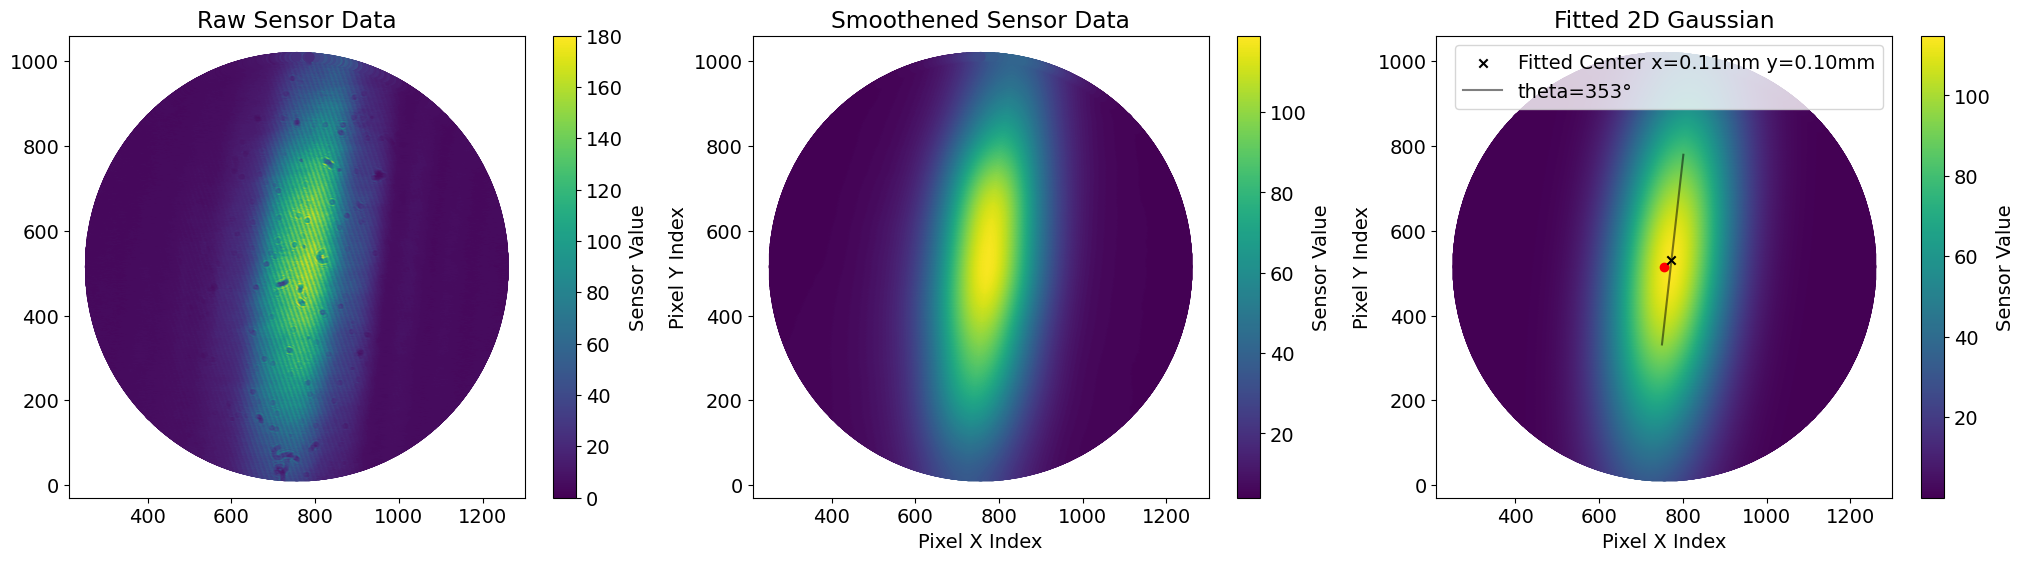

In [9]:

import cv2


# file_path = "beam_profile/Image_2026-03-17_11.06.22_DET_vertical_expanded_0.5mW.bmp"
file_path = "beam_profile/DeviceData_2026-04-08_12.28.03_#001.bmp"
# Open the image file
image = Image.open(file_path)

# Convert the image to grayscale (optional, if you need a 2D array)
image = image.convert('L')
# Convert the image to a NumPy array
image_array = np.array(image)
image_array = image_array[::-1, :]
sensor_array = image_array

# Converting the array to uint8 format needed for OpenCV
image = (sensor_array).astype(np.uint8)

# Apply thresholding to create a binary mask of the non-zero data
_, thresholded = cv2.threshold(image, 60, 255, cv2.THRESH_BINARY)

# Find contours of the thresholded image to locate the non-zero areas
contours, _ = cv2.findContours(thresholded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Combine all contours into one to get a single enclosing circle
all_points = np.vstack(contours)

# Find the minimum enclosing circle that covers all combined contours
(x, y), radius = cv2.minEnclosingCircle(all_points)
center = (int(x), int(y))
radius = int(radius)

# Draw the enclosing circle on the original image
output_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)  # Convert to BGR for colored circle visualization
cv2.circle(output_image, center, radius, (0, 255, 0), 2)


pixel_x_size, pixel_y_size = 8.77e-3/1360, 6.6e-3/1024

# Define a 2D Gaussian function
def gaussian_2d(xy, amplitude, xo, yo, sigma_x, sigma_y):
    x, y = xy
    xo = float(xo)
    yo = float(yo)
    g = amplitude * np.exp(-(((x - xo) ** 2) / (2 * sigma_x ** 2) + ((y - yo) ** 2) / (2 * sigma_y ** 2)))
    return g.ravel()

# Define the 2D Gaussian function with rotation
def gaussian_2d_rotated(coords, A, x0, y0, sigma_x, sigma_y, theta):
    x, y = coords
    a = np.cos(theta)**2 / (2*sigma_x**2) + np.sin(theta)**2 / (2*sigma_y**2)
    b = np.sin(2*theta) / (2*sigma_x**2) - np.sin(2*theta) / (2*sigma_y**2)
    c = np.sin(theta)**2 / (2*sigma_x**2) + np.cos(theta)**2 / (2*sigma_y**2)

    g = A * np.exp(- a*(x-x0)**2 - b*(x-x0)*(y-y0) - c*(y-y0)**2)
    return g.ravel()

# Initial guess for the Gaussian parameters
initial_guess = (80, 600, 400, 200, 200, 2)  # (A, x0, y0, sigma_x, sigma_y, theta)
# initial_guess = (20, 600, 600, 20, 20)  # (A, x0, y0, sigma_x, sigma_y)

img = ndimage.gaussian_filter(sensor_array, sigma=(50, 50), order=0)

# Generate a grid of x, y coordinates
x = np.arange(img.shape[1])
y = np.arange(img.shape[0])
x, y = np.meshgrid(x, y)

# Create a mask to select data within the circle
mask = (x - center[0])**2 + (y - center[1])**2 <= radius**2

# Apply the mask to extract the relevant data
x_data = x[mask]
y_data = y[mask]
z_data = img[mask]


# Fit the Gaussian model to the data
popt, pcov = curve_fit(gaussian_2d_rotated, (x_data, y_data), z_data, p0=initial_guess, bounds=([-np.inf, -np.inf, -np.inf, -np.inf, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf, np.inf, 2*np.pi]))
# popt, pcov = curve_fit(gaussian_2d, (x_data, y_data), z_data, p0=initial_guess)


# # Extract the fitted parameters
amplitude, xo, yo, sigma_x, sigma_y, theta = popt

# Generate fitted data for visualization
z_fitted = gaussian_2d_rotated((x, y), *popt).reshape(sensor_array.shape)


# # Plot fitted Gaussian
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 6))
scatter1 = ax1.scatter(x_data, y_data, c=sensor_array[mask], vmin=0, vmax=180, cmap='viridis')
ax1.set_title('Raw Sensor Data')
ax2.set_xlabel('Pixel X Index')
ax2.set_ylabel('Pixel Y Index')
fig.colorbar(scatter1, ax=ax1, label='Sensor Value')

scatter2 = ax2.scatter(x_data, y_data, c=z_data, cmap='viridis')
ax2.set_title('Smoothened Sensor Data')
ax2.set_xlabel('Pixel X Index')
ax2.set_ylabel('Pixel Y Index')
fig.colorbar(scatter2, ax=ax2, label='Sensor Value')

scatter3 = ax3.scatter(x_data, y_data, c=z_fitted[mask], cmap='viridis')
ax3.set_title('Fitted 2D Gaussian')
ax3.set_xlabel('Pixel X Index')
ax3.set_ylabel('Pixel Y Index')     
ax3.scatter(center[0], center[1], color='red', marker='o') 
ax3.scatter(popt[1], popt[2], color='black', marker='x', label=f'Fitted Center x={(xo-center[0])*pixel_x_size*1e3:.2f}mm y={(yo-center[1])*pixel_y_size*1e3:.2f}mm') 
ax3.plot(popt[1]+np.arange(-250,250,50)*np.sin(theta), popt[2]-np.arange(-250,250,50)*np.cos(theta), color='black', alpha=0.5, label=f'theta={int(theta*180/np.pi)}°')
fig.colorbar(scatter3, ax=ax3, label='Sensor Value')
ax3.legend()


In [10]:
sensor_array.shape

(1024, 1360)

In [11]:
popt

array([114.84355997, 772.81418715, 530.53080254, 100.63087236,
       321.63869371,   6.16945867])

In [12]:
image.shape

(1024, 1360)

In [13]:
image.shape[0]*pixel_x_size

0.006603294117647059

In [14]:
(yo-center[1])*pixel_y_size

0.00010010087571409741

In [15]:
sigma_x*pixel_x_size, sigma_y*pixel_y_size

(0.0006489211401417413, 0.0020730618930741604)

# Scan Frequency 

In [16]:
def get_diagonal_indices_flattened(size, states=None, mode="python"):
    if states is None:
        indices = [i + size * i for i in range(size)]
    else:
        indices = [i + size * i for i in states]
    if mode == "julia":
        return [i + 1 for i in indices]
    elif mode == "python":
        return indices
state_selector = states.QuantumSelector(electronic=states.ElectronicState.B)
indices = state_selector.get_indices(obe_system.QN)
save_idxs = get_diagonal_indices_flattened(len(obe_system.QN), indices, mode="julia")

## Run simulation

In [17]:
sigma_x*pixel_x_size*np.sqrt(2), sigma_y*pixel_y_size*np.sqrt(2)

(0.0009177130772990625, 0.0029317522448243207)

In [18]:
odepars.σz, odepars.σy

(0.000453, 0.00104)

In [19]:
from rich import progress
frequencies = np.arange(-5, 5, 0.01) * 2 * np.pi * 1e6 * 4 
vz = 185
def scan_function(laser_power, y0):

    ρ = utils.population.generate_uniform_population_states(
        states.QuantumSelector(J=2, F=3, electronic=states.ElectronicState.X), obe_system.QN
    )
    stop_function = "vz*t + z0 >= 2e-2"

    callback = lindblad_julia.setup_discrete_callback_terminate(
        odepars=odepars, stop_expression=stop_function
    )
    odepars.σz, odepars.σy = sigma_x*pixel_x_size*np.sqrt(2), sigma_y*pixel_y_size*np.sqrt(2)
    odepars.β = 0
    odepars.θ = theta
    odepars.laser_center_z, odepars.laser_center_y = -(xo-center[0])*pixel_x_size, (yo-center[1])*pixel_y_size
    odepars.y0 = y0
    power = laser_power*1e-3


    peak_intensity = power / (2 * np.pi * odepars.σz * odepars.σy)

    odepars.peak_intensity = peak_intensity

    ensemble_config = lindblad_julia.OBEEnsembleProblemConfig(
        method="Tsit5()",
        save_idxs=save_idxs,
        saveat=1e-6,
        abstol=1e-10,
        reltol=1e-7,
        callback=callback,
    )

    problem = lindblad_julia.OBEProblem(odepars, ρ, tspan=(0, 500e-6))

    scan_values = [frequencies]
    parameters = ["laser_detuning"]

    output_func = lindblad_julia.setup_state_integral_calculation_state_idxs(
        nphotons=True
    )

    ensemble_problem = lindblad_julia.OBEEnsembleProblem(
        problem=problem,
        parameters=parameters,
        scan_values=scan_values,
        output_func=output_func,
        zipped=True,
    )

    lindblad_julia.setup_problem_parameter_scan(ensemble_problem)

    lindblad_julia.solve_problem_parameter_scan(ensemble_problem, ensemble_config)

    results = lindblad_julia.get_results_parameter_scan(ensemble_problem)
    return results
# with open("results_scan_freq.pkl", "wb") as f:
#     pickle.dump(results_scan, f)

In [20]:
import pandas as pd
import numpy as np
from rich import progress
from scipy.interpolate import LinearNDInterpolator
y0s = np.append(np.arange(0, 3, 0.2), np.arange(3, 5, 0.5)) * 1e-2 # [cm to m]

class TaskSpeed(progress.ProgressColumn):
    def render(self, task):
        if task.speed is None:
            return ""
        elif task.speed >= 0.1:
            return f"{(task.speed or 0):.1f}/s"
        else:
            return f"{(1 / task.speed or 0):.1f} s/i"

# --- Main Script ---
all_records = [] # This list will store all the data points in memory

with progress.Progress(progress.TextColumn("[progress.description]{task.description}"),
        progress.BarColumn(bar_width=None),
        progress.TaskProgressColumn(),
        progress.MofNCompleteColumn(),
        progress.TimeElapsedColumn(),
        progress.TimeRemainingColumn(),) as pb:
    task_description = "[cyan]Scanning..."
    main_task = pb.add_task(task_description, total=len(y0s), speed=TaskSpeed())

    for y0 in y0s:
        # 1. Run your scan function to get the result array
        result_data = scan_function(laser_power=0.5, y0=y0).results
        
        # 2. Flatten the data and append records to the list
        # For each result in the array, create a dictionary (a row)
        for frequency, result_value in zip(frequencies, result_data):
            all_records.append({
                'vz': vz,
                'y0': y0,
                'frequency': frequency,
                'result': result_value
            })
        
        pb.advance(main_task, 1)

# --- Save the results after the scan is complete ---
print("\nScan complete. Converting to DataFrame and saving to Parquet...")

# 3. Convert the list of records into a Pandas DataFrame
df = pd.DataFrame(all_records)

# Build a 2D interpolator on (y0, frequency) and wrap it so it keeps a 3-arg signature (vz, y0, frequency)
df['frequency'] = df['frequency'] / (2 * np.pi * 1e6 * 4) 
points_2d = df[['y0', 'frequency']].values

values = df['result'].values


interp2 = LinearNDInterpolator(points_2d, values)

pickle.dump(interp2, open("2d_interpolator_0.5mW_sigma_2.8mm.pkl", "wb"))



Output()


Scan complete. Converting to DataFrame and saving to Parquet...


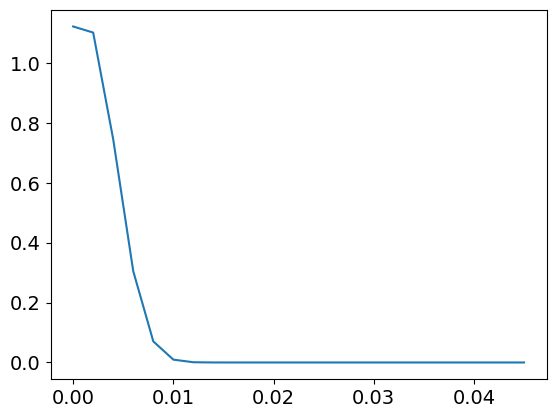

In [21]:
y0s = np.append(np.arange(0, 3, 0.2), np.arange(3, 5, 0.5)) * 1e-2 # [cm to m]

plt.plot(y0s, interp2(y0s, 0))

In [22]:
import pickle
with open("detuning_simu_vertical_expanded_beam.pkl", "rb") as f:
    interp2 = pickle.load(f)